Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [2]:
NAME = "Angelina Podolako"
STUDENT_NUMBER = "s1125886"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Notebooks to make your assignments, it might remove the auto-grading metadata. To prevent this, please copy the answers back into the original notebook.
- Only type your answers in places where asked.   

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You can remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 3: Naive Bayes and Trees

### Deadline: October 17th (so you can work on this one for 3 workgroups)

In this assignment, we will be implementing two different algorithms and delve a little bit more into programming.

We will first explore Naive Bayes using a simple dataset and a real dataset.

Note: this example is completely made up in a way such that your answer is easy to inspect.

In [7]:
import numpy as np

spam_dataset = [
    ["free", "money"],
    ["dear", "friend"],
    ["friend", "free"],
    ["dear", "friend"],
    ["free", "money"],
]

dictionary = {"dear": 0, "friend": 1, "free": 2, "money": 3}
y = np.array([True, False, False, False, True])

### Exercise 1.1.1

Using the `dictionary`, create the vector encoding of the spam dataset and save it as a numpy array `X`.

For each data point, we create an array with a length equal to the number of key-value pairs in the dictionary.
The array's contents will be $0$ for each word that is not present in the message, and $1$ for each word that is present in the message.

For example, the message `['dear', 'friend']` should be encoded as `[1, 1, 0, 0]`, and we will end up with a matrix of shape `(5,4)` filled with ones and zeros. 

In [10]:
X = None

# YOUR CODE HERE
X = np.zeros((len(spam_dataset),len(dictionary)))
for i, message in enumerate(spam_dataset):
    for word in message:
        if word in dictionary:
            X[i][dictionary[word]]=1
X

array([[0., 0., 1., 1.],
       [1., 1., 0., 0.],
       [0., 1., 1., 0.],
       [1., 1., 0., 0.],
       [0., 0., 1., 1.]])

In [12]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.1.2

__Note: in case you get stuck here, continue with Exercise 1.2.1.__
### Explanation about OOP in Python and SK Learn:

Previously, we implemented our models using a function that computes the weights, and another separate function that computes the prediction. We ignored best practices.

When using the scikit modules in the previous exercises, you might have noticed that all of these modules create a class instance of a model. 

For example, in the logistic regression module you used last week, you would make an instance of the class using

```
clf = LogisticRegression(random_state=0).fit(X, y)
```

`clf` is now an instance of the class `LogisticRegression` and the weights are stored in there as member variables. 
When we call the `predict` method, we don't have to pass in the weights as a parameter ourselves.

In case you have never used classes in Python before, be sure to look at the documentation, but it's fairly straight-forward if you know how to make a function.
Python classes do not use public/protected/private, everything is public. 
There are code style conventions to mark something as intended private, we will not worry about that.

When declaring an instance method for a class, the first parameter will usually be named `self` to represent the class instance you can access variables of.

### Exercise:

We will create our own class for the Naive Bayes predictor.

We already made the method `class_weights`, with parameters `X`, `y`, and `label`. Note that `class` here means the classification class (So belonging to class $C_0$, or having `label = 0`, means not being spam. And belonging to class $C_1$, or having or having `label = 1`, means it's spam) and not the Object Oriented Programming class.

Next we made the Laplace smoothing function as used in `class_weights`, to prevent 0 probabilities showing up. The smoothing rate can be changed when initializing an instance of `NaiveBayesPredictor`, but it set on a very small number as default. 

We also made the `fit` function, which will fit Naive Bayes on a given dataset `X` and `y`. It will compute the `class_probabilites` $p(C_i)$, which is the prior probability of a sample belonging to a class (so $p(c_1)=p(spam) = \frac{2}{5}$) and the `word_weights` $p(x_j|C_i)$ (so the probability of $x_0=$ dear being in a message with label `0` or `not_spam` is $p(x_0|C_0) = \frac{2}{6}$).

More specifically, In our example `X`, there are 3 samples in the class `y == 0` (i.e., non-spam), `words_per_class` is `[2. 3. 1. 0.]`. The probabilities of a sample containing one of these words while not being spam are $p(dear|C_0) = \frac{2}{6}$, $p(friend|C_0)=\frac{3}{6}$, $p(free|C_0)=\frac{1}{6}$ and $p(money|C_0)=\frac{0}{6}$ respectively. There are 2 samples in the class `y == 1` (i.e., spam), `words_per_class` is `[0. 0. 2. 2.]`. The probabilities of a sample containing one of these words while being spam are $p(dear|C_1) = \frac{0}{4}$, $p(friend|C_1)=\frac{0}{4}$, $p(free|C_1)=\frac{2}{4}$ and $p(money|C_1)=\frac{2}{4}$ respectively.

Before implementing the Predict Method, you can already run the cell below and answer __exercise 1.1.3__. When you feel comfortable with what `class_probabilities` and `word_weights` represent, move on to the part below: 

#### Predict method

We now implement the method `predict`, with parameters `self` and `X`.
`X` could be an evaluation or test set. 
Our goal is to predict the most likely class for each data point.
For that, compute the following things:
1. For each class $C_i$, compute the probability of each word $x_j \in \vec{x}$, where $\vec{x}$ is a new sentence, belongs to that class using $$ p(C_i) \prod p(x_j | C_i) $$
 $p(C_i)$ is stored in the parameter `self.class_probabilities`, and $p(x_j | C_i) $ is stored in `self.word_weights_false` and `self.word_weights_true`.

3. You should now have two numpy arrays of shape $(N,)$, one that predicts the probability of $\vec{x}$ being `False`, and one that predicts the probability of $\vec{x}$ being `True`. Combine these into a single numpy array of shape $(N,2)$, for example using Numpy stack. 
4. Return a numpy array `predicted_class` of shape $(N,)$, with $N$ the number of samples in the input. The elements in this array should be $0$ if the sample is most likely `False`, and $1$ if the sample is most likely `True`. One possible method is using numpy argmax. 

In [15]:
class NaiveBayesPredictor:
    def __init__(self, smooth=0.000001):
        self.smooth = smooth
        self.word_weights_true = None  # This will be a numpy array with shape (N,1)
        self.word_weights_false = None  # This will be a numpy array with shape (N,1)
        self.class_probabilities = None  # This will be a numpy array with shape (1,2)

    def laplace_smoothing(self, words_per_class):
        # Compute the total number of words d in our dictionary
        len_words_per_class = len(words_per_class)
        # Smooth the sum by add d*smooth
        smoothed_sum = np.sum(words_per_class) + len_words_per_class * self.smooth
        # Smooth the values by adding smooth
        smoothed_words_per_class = words_per_class + self.smooth
        # Compute the new probabilities
        smoothed_probabilities = smoothed_words_per_class * (1 / smoothed_sum)
        return smoothed_probabilities

    def class_weights(self, X, y, label):
        #  Compute the number of times a word appears per class
        words_per_class = np.sum(X[y == label], axis=0)
        # Compute the total number of samples in this category
        total_samples_in_class = np.sum(y == label)
        # Smooth the word counts to a probability
        smoothed_probabilities = self.laplace_smoothing(words_per_class)
        return smoothed_probabilities, total_samples_in_class

    def fit(self, X, y):
        # Compute the word weights for False
        self.word_weights_false, total_words_false = self.class_weights(X, y, 0)
        # Compute the word weights for True
        self.word_weights_true, total_words_true = self.class_weights(X, y, 1)
        # Compute the class priors
        word_counts = np.array([total_words_false, total_words_true])
        self.class_probabilities = np.array(word_counts / np.sum(word_counts)).T

    def predict(self, X):
        # YOUR CODE HERE
        false_class_probabilities = np.zeros(X.shape[0])  #length = rows in X
        true_class_probabilities = np.zeros(X.shape[0]) #probs for class True
    
        for row in range(X.shape[0]):
            #for every msg in X - start with prior class probs
            false_class_probabilities[row] = self.class_probabilities[0]  # p(C=False); p(Ck)=prior class
            true_class_probabilities[row] = self.class_probabilities[1]    # p(C=True); 
    
            for col in range(X.shape[1]): #for every word(in row in col) in msg
                if X[row][col] > 0:  # if word is in msg, then prob(class)* prob(x|class)
                    false_class_probabilities[row] *= self.word_weights_false[col]  # False lass-not spam
                    true_class_probabilities[row] *= self.word_weights_true[col]   # True -spam
                    
        probabilities = np.stack((false_class_probabilities, true_class_probabilities),  axis = 1) #combine in one array (N, 2)
        predicted_class = np.argmax(probabilities) #save highest prob to each row
            # 0 -not spam; 1-spam
        return predicted_class

### Exercise 1.1.3

Make an instance of the class NaiveBayesPredictor called `nbp`. Fit your predictor on the `X` and `y` we constructed above, and inspect the `class_probabilites`, `word_weights_false` and `word_weights_true`. 

In [18]:
nbp = None
class_probabilities = None
word_weights_false = None
word_weights_true = None


# YOUR CODE HERE
nbp = NaiveBayesPredictor()
nbp.fit(X,y)
class_probabilities = nbp.class_probabilities #0.6 not spam = false; 0/4 -spam -true
word_weights_false = nbp.word_weights_false
word_weights_true = nbp.word_weights_true

# The following line will make sure that the smoothed weights are easier to read. 
np.set_printoptions(precision=3, suppress=True)

print(class_probabilities, word_weights_false, word_weights_true)

[0.6 0.4] [0.333 0.5   0.167 0.   ] [0.  0.  0.5 0.5]


In [20]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.1.4
Suppose we get these new messages:

```
 [['dear', 'friend'],
  ['free', 'money'],
  ['dear', 'friend', 'free', 'money'],
  ['money'],
  ['free', 'money'],
  ['friend', 'money']]
```

Use your found weights to predict the results

In [23]:
X_test = np.array(
    [[1, 1, 0, 0], [1, 0, 0, 1], [1, 1, 1, 1], [0, 0, 0, 1], [0, 0, 1, 1], [0, 1, 0, 1]]
)

y_pred = None

# YOUR CODE HERE
y_pred = nbp.predict(X_test)
print(y_pred)

7


In [25]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.2.1

In this exercise, we will try using Multinomial Naive Bayes on an edited version of a real dataset, check out the real dataset on kaggle [here](https://www.kaggle.com/datasets/elvinrustam/books-dataset). 

We have provided the following two extra rows for you: 
1. Cleaned_Description: Here, we have performed some common Natural Language Processing methods to make the data better for processing (You will learn more about this in your NLP course)
2. A column `Fiction`, where we have the label we are going to predict. 

In [28]:
import pandas as pd

books = pd.read_csv("mini_book_dataset.csv")
books

,Title,Authors,Description,Cleaned_Description,Fiction
0,Journey Through Heartsongs,"By Stepanek, Mattie J. T.",Collects poems written by the eleven-year-old ...,collect poem written elevenyearold muscular dy...,False
1,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and...",The Russian author offers an affectionate chro...,the russian author offer affectionate chronicl...,False
2,Germs : Biological Weapons and America's Secre...,"By Miller, Judith, Engelberg, Stephen, and Bro...","Deadly germs sprayed in shopping malls, bomb-l...",deadly germ sprayed shopping mall bomblet spew...,False
3,The Good Book: Reading the Bible with Mind and...,"By Gomes, Peter J.","""The Bible and the social and moral consequenc...",the bible social moral consequence derive inte...,False
4,Hill Rat: Blowing the Lid Off Congress,"By Jackley, John L.",As a top aide to powerful Texas Congressman Ro...,a top aide powerful texas congressman ronald c...,False
...,...,...,...,...,...
3995,Vinegars,"By Gordon-Smith, Clare",Explains how to use the growing assortment of ...,explains use growing assortment vinegar enhanc...,False
3996,The Herbal Grove: A Celebration of the Beauty ...,"By Forsell, Mary and Cenicola, Tony (PHT)",The Herbal Grove is a lavishly illustrated wor...,the herbal grove lavishly illustrated work fun...,False
3997,"Relax, This Won't Hurt: Painless Answers to Wo...","By Reichman, Judith, M.D.","From a doctor millions of women already trust,...",from doctor million woman already trust relax ...,False
3998,Open: Inside the Ropes at Bethpage Black,"By Feinstein, John","With Open, John Feinstein goes behind the scen...",with open john feinstein go behind scene tell ...,False


## Exercise 1.2.1

As we explained, we did some pre-processing on the data for you, to make your life easier.
Take a look at the first three elements of Description and Cleaned Description. 
What type of preprocessing do you think occurred?

In [82]:
# YOUR CODE HERE

print(books["Description"].head(3))
print(books["Cleaned_Description"].head(3))

0    Collects poems written by the eleven-year-old ...
1    The Russian author offers an affectionate chro...
2    Deadly germs sprayed in shopping malls, bomb-l...
Name: Description, dtype: object
0    collect poem written elevenyearold muscular dy...
1    the russian author offer affectionate chronicl...
2    deadly germ sprayed shopping mall bomblet spew...
Name: Cleaned_Description, dtype: object


As I noticed and realized that the main thing that has changed, that is, it has been processed, is that all punctuation marks have disappeared, as well as other characters of signs, such as dashes. Also, the entire text is written in one font, or to be more precise, in lowercase, that is, not capital letters. In addition, there are no articles, other prepositions (short words).

# Exercise 1.2.2

As always, we first need to do a train test split.
Make a numpy array called books_X, which stores all entries in the `Cleaned_Description` column, and the array `y`, which stores the `Fiction` column. Make sure that `book_X_train` and `y_train` both have shape `(3000,)`

Then, make a train-test split with a test size of 0.25 and a random state of 42.

In [86]:
import numpy as np
from sklearn.model_selection import train_test_split

books_X = None
y = None
books_X_train, books_X_test, y_train, y_test = None, None, None, None
test_size = 0.25
random_state = 42


# YOUR CODE HERE
books_X = np.array(books["Cleaned_Description"])
y = np.array(books["Fiction"])
books_X_train, books_X_test, y_train, y_test = train_test_split(books_X, y, test_size = test_size, random_state = random_state )
test_size = 0.25
random_state = 42


books_X_train.shape, y_train.shape

((3000,), (3000,))

In [88]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

# Exercise 1.2.3

Instead of having to do the vectorization manually, we will use the sklearn [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html). This one has some handy features like only using the most common 2000 words. 
If we don't do this, we might end up with vectors over 100 000 long, which would be costly to do any computations with.

Remember, to prevent premature featurization, to fit this vectorizer on `books_X_train` and then transform it onto `books_X_test`, using `max_features` of 2000.

In [91]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = None
max_features = 2000
# YOUR CODE HERE
vectorizer = CountVectorizer(max_features = max_features)

books_X_train_transformed = vectorizer.fit_transform(books_X_train) #fit this vectorizer on books_X_train
books_X_test_transrofmed = vectorizer.transform(books_X_test) #then transform it onto books_X_test DO I NEED TO MAKE NEW VARIABLE???? books_X_test_transformed

unique_words = vectorizer.get_feature_names_out()
print(unique_words)

['10' '100' '100000' ... 'youre' 'youth' 'youve']


In [93]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

## Exercise 1.2.3

Using the [Multinomial Naive Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) in SKlearn, fit Naive Bayes on the train set, and predict the test set as `y_pred`. 

In [96]:
from sklearn.naive_bayes import MultinomialNB

y_pred = None
# YOUR CODE HERE
y_pred = MultinomialNB().fit(books_X_train_transformed, y_train).predict(books_X_test_transrofmed)

In [98]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

## Exercise 1.2.4

Using sklearn `confusion_matrix`, compute the confusion matrix. 

In [101]:
from sklearn.metrics import confusion_matrix

cfm = None
# YOUR CODE HERE
cfm = confusion_matrix(y_test, y_pred)

In [103]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Use the following cell to inspect your confusion matrix:

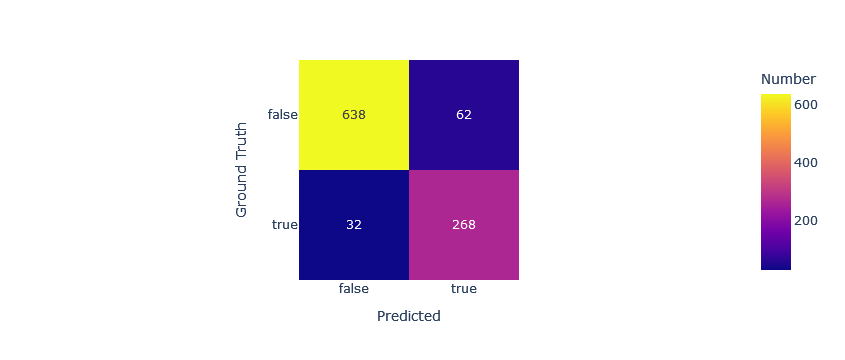

In [106]:
import plotly.express as px

fig = px.imshow(
    cfm,
    labels=dict(x="Predicted", y="Ground Truth", color="Number"),
    x=[False, True],
    y=[False, True],
    text_auto=True,
)
fig.show()

### Exercise 1.2.5: __(Extra: not graded)__

Are you interested in which words would be the best predictors for `Fiction` and `Non Fiction`? In the class we made back in 1.1, we explicitely saved the word weights. 

Unfortunately, the official package does not do that. 
If we still want to get some idea of which features have the most influence in classifying an input as `Fiction` and `Non Fiction`, we can try making a prediction for the unity matrix $I$. (So this would represent a dataset of 2000 sentences, the first one just contains the first word, the second just the second, etc.). 

Try making a prediction for $I$ using [predict_proba](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html), and using `unique_words` which we made before, try doing some exploration in which words have most influence on predicting either category. Something like [argsort](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) might help, but there are multiple options. 

If you want to spend even more time on this, try seeing for some false positives and false negatives as predicted above, if you can find examples where you can explain why it was predicted in the wrong class. 


In [109]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

# week 6:

The part after this week is for week 6. You can work ahead, but your TA might not be able to answer your questions yet.

### Exercise 2

Back to the penguin dataset again, but this time, we will look at decision trees. 
Instead of implementing the entire decision tree ourselves, we will only look at the impurity measures. For this, we will use our trusty Penguin dataset again.
Since we will only take a look at the effect of the Gini and Entropy impurity, we will not make a train/test split and also just remove the missing values. 


In [112]:
penguins = pd.read_csv("penguin.csv")

penguins_processed = penguins.dropna().copy()
penguins_processed["Adelie"] = penguins_processed["species"] == "Adelie"
y = penguins_processed["Adelie"].to_numpy().astype(int)
X = penguins_processed["flipper_length_mm"].to_numpy()

### Exercise 2.1.1

(Again, in case you get stuck here, continue with 2.2)

Take a look at the violin plot below. In a violin plot we can see the box plot, the density function and the datapoints scattered (with a bit of randomness). Read more about violin plots [here](https://en.wikipedia.org/wiki/Violin_plot).

If you were to decide on a threshold that can split the dataset with the least amount of impurity, what would you think it would be?


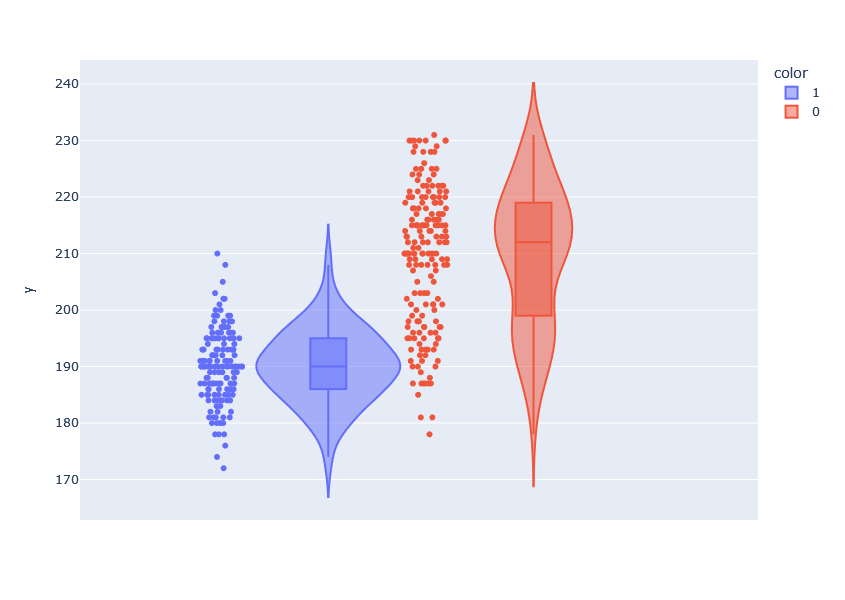

In [115]:
fig = px.violin(y=X, color=y, box=True, points="all")
fig.update_layout(
    autosize=False,
    width=600,
    height=600,
)
fig.show()

In [117]:
# Make an estimate here for a threshold

estimated_best_threshold = 0

# YOUR CODE HERE
estimated_best_threshold = 198

In [119]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.2

Suppose we split our dataset $X$ into two splits, $D_1$ and $D_2$, of which $D_1 \cup D2 = X, D_1 \cap D2 = \emptyset$. 
The GINI for one leaf will then be

$$ GINI(D) = 1 - p(true|D)^2 - p(false|D)^2$$

The GINI for the entire split will be:

$$ GINI = \sum_{D_i \in {D_1, D_2}} p(D_i)*GINI(D_i)$$

Since the GINI and the Entropy score later are fairly similar, we will reuse the same `score_split` function to score a certain split. We only change the function for scoring the individual leaves.

Implement the `gini_one_split` function, which computes the $GINI(D)$ for one leaf.


In [122]:
def gini_one_split(y):
    # Return the GINI value given a split
    # YOUR CODE HERE
    n = len(y) #sum of all t and f answers
 
    p_true = sum(y) / n #sum ones and divide by overall numb
    p_false = 1 - p_true  # p(f|D)= 1 - p(t|D) bcse hard sum zeros:)

    gini_for_one =1 - p_true**2 - p_false**2 
    
    return gini_for_one #gini for one leaf

In [124]:
def score_split(X, y, threshold, split):
    y_above_thresh = y[X > threshold]
    y_below_thresh = y[X <= threshold]
    below = split(y_below_thresh)
    above = split(y_above_thresh)
    p_above_thresh = len(y_above_thresh) / len(y)
    p_below_thresh = len(y_below_thresh) / len(y)
    total = p_above_thresh * above + p_below_thresh * below
    return total

def gini(X, y, threshold):
    return score_split(X, y, threshold, gini_one_split)

In [126]:
### Test your gini, your estimated best should be the lowest

print(gini(X, y, estimated_best_threshold))
print(gini(X, y, estimated_best_threshold + 10))
print(gini(X, y, estimated_best_threshold - 10))

0.27676497508899733
0.29757567699330767
0.4128702824696542


In [128]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.3

We want to be able to inspect every single possible point where we can split our data. For that, we will create a numpy array `X_point_means` as follows:
1. Make an array of all values in `X` sorted in ascending order (Make sure to copy it, and not to change X), call it `X_sorted`
2. Compute, for each consecutive two elements in `X_sorted`, the mean. So
3. 
   ${X\_points\_mean} = [\frac{x_0+x_1}{2},\frac{x_1+x_2}{2}, \dots ]$ for $x_i \in {X\_sorted}$



In [131]:
X_sorted = None
X_point_means = None
# YOUR CODE HERE
X_sorted = np.sort( np.copy(X) )
X_point_means = np.zeros(X_sorted.shape[0] - 1)

for i in range(len(X_sorted)-1):
    two_x_mean = (X_sorted[i] + X_sorted[i+1]) * 0.5
    X_point_means[i] = two_x_mean


print(X_sorted[0:5], X_point_means[0:5])

[172. 174. 176. 178. 178.] [173. 175. 177. 178. 178.]


In [133]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

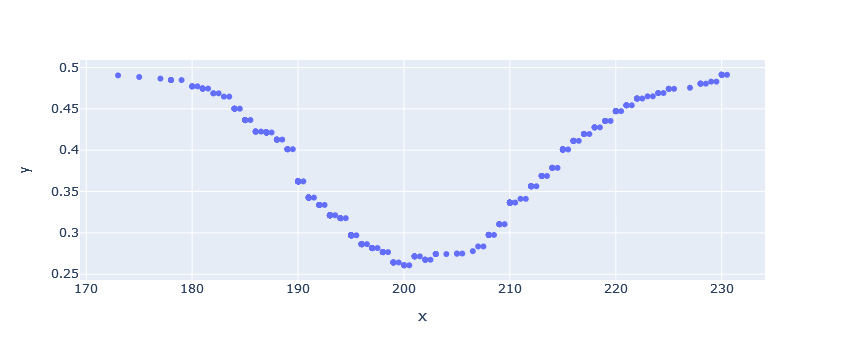

In [135]:
### Computing the GINI impurities for all splits in X_point_means and inspecting the best split:

gini_impurities = [gini(X, y, thresh) for thresh in X_point_means]

fig = px.scatter(x=X_point_means, y=gini_impurities)
fig.show()

### Exercise 2.1.4


Suppose we split our dataset $X$ into two splits, $D_1$ and $D_2$, of which $D_1 \cup D_2 = X, D_1 \cap D_2 = \emptyset$. 
The GINI for one leaf will then be

$$Entropy(D) =  -p(true|D)log_2(p(true|D)) - p(false|D)log_2(p(false|D))$$


The Entropy for the entire split will be:

$$ Entropy = \sum_{D_i \in {D_1, D_2}} p(D_i)*Entropy(D_i)$$

As you see, the formula for computing the Entropy on both sets, is the same as computing the Gini on both sets. So we can reuse this `score_split` function. 

Implement the `Entropy` function given one split, and then use the `score_split` function to compute the total entropy on both splits. Don't forget to use smoothing, to prevent taking a logarithm of 0.

In [138]:
def entropy_one_split(y, smooth=0.00001):
    # YOUR CODE HERE
    n = len(y) #sum of all t and f answers
    # smooth = (x+smooth) / (n + categories * smooth)    
    p_true = (sum(y) + smooth) / (n + 2 * smooth) #sum ones and divide by overall numb
    p_false = (n - sum(y) + smooth) / (n + 2 * smooth)  # p(f|D)= 1 - p(t|D) bcse hard sum zeros:)

    entropy_for_one = -p_true * np.log2(p_true) - p_false * np.log2(p_false)
    return entropy_for_one #entropy for one leaf

In [140]:
def entropy(X, y, threshold):
    # YOUR CODE HERE
    return score_split(X, y, threshold, entropy_one_split)

In [142]:
### Test your entropy, your estimated best should be the lowest

print(entropy(X, y, estimated_best_threshold))
print(entropy(X, y, estimated_best_threshold + 10))
print(entropy(X, y, estimated_best_threshold - 10))

0.6350429924998845
0.6270334432590955
0.8670893558913002


In [144]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [146]:
entropies = [entropy(X, y, thresh) for thresh in X_point_means]

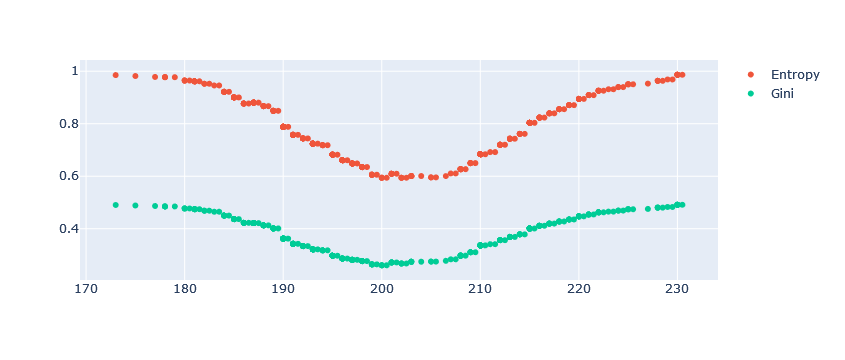

In [148]:
# Inspect the plot below:

fig = px.scatter()
fig.add_scatter(x=X_point_means, y=entropies, mode="markers", name="Entropy")
fig.add_scatter(x=X_point_means, y=gini_impurities, mode="markers", name="Gini")
fig.show()

Given the plot above, would the best guessed value for the split change?Yes, I was wrong, not much (I choosed 198), but the best separation will be at  level 202

## Exercise 2.2
### Using the package 

Again, like previous times, we will also see how the common package in numpy works. Last time, we tried predicting only one type of penguin.
Now we will do multi class prediction, so we will predict for each type of penguin. 
For that, we need to encode our Y vector with a one_hot encoding. Using OneHotEncoder in sklearn, make an onehot encoding of Y, and call the instance of the encoder class `enc`. Then, make a train/test split with the given test_size and random_state

In [152]:
from sklearn.preprocessing import OneHotEncoder

test_size = 0.25
random_state = 42

islands = ["Torgersen", "Biscoe", "Dream"]  # Manual One Hot encoding for the columns
for island in islands:
    penguins[island] = penguins["island"] == island
feature_names = [
    "flipper_length_mm",
    "bill_depth_mm",
    "body_mass_g",
    "bill_depth_mm",
] + islands
X = penguins[feature_names].to_numpy()


enc = None  # Use this for the instance of your one_hot encoder
y_onehot = None  # Use this for the actual one hot encoding.

# YOUR CODE HERE

enc = OneHotEncoder()  # Use this for the instance of your one_hot encoder
y =  penguins['species'].values.reshape(-1, 1)
y_onehot = enc.fit_transform(y).toarray()  # Use this for the actual one hot encoding.
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size = test_size, random_state = random_state)

class_names = enc.categories_[0]

In [154]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2.1

Train a decision tree on our given train data using the [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
Play around with the parameters criterion (which is splitting using either gini or max_depth), max_depth.

Which of these parameters works the best? Does a deeper tree depth mean that the model works better on the test set?

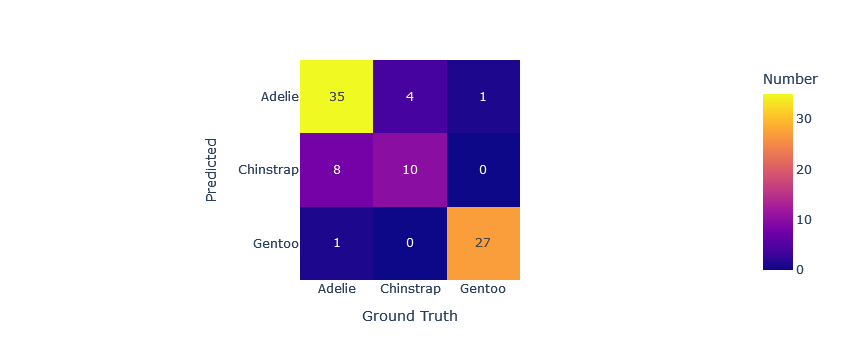

Multi class accuracy of 0.837


In [157]:
from sklearn import tree

max_depth = 1
criterion = "gini"  # [“gini”, “entropy”,]


# YOUR CODE HERE
max_depth = 7
criterion = "gini" #"entropy"
"""
In cell 191 
for island in islands:
    penguins[island] = penguins["island"] == island
feature_names = [
    "flipper_length_mm",
    "bill_depth_mm",
    "body_mass_g",
    "bill_depth_mm",
]+ islands

bill_length_mm counts two times, I hope this is an error.
"""

clf = tree.DecisionTreeClassifier(criterion=criterion, max_depth=max_depth)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test) 


# Encoding back the labels
y_pred_labels = enc.inverse_transform(y_pred)
y_test_labels = enc.inverse_transform(y_test)


# Making a confusion matrix
cfm = confusion_matrix(y_test_labels, y_pred_labels, labels=class_names)

fig = px.imshow(
    cfm,
    labels=dict(x="Ground Truth", y="Predicted", color="Number"),
    x=class_names,
    y=class_names,
    text_auto=True,
)
fig.show()

# Computing the multi class accuracy
multi_class_accuracy = np.trace(cfm) / np.sum(cfm)

print(f"Multi class accuracy of {multi_class_accuracy:.3f}")

In [159]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2.2
You can use the following two cells inspect the final model you trained.

[Text(0.4230769230769231, 0.875, 'flipper_length_mm <= 206.5\ngini = 0.424\nsamples = 258\nvalue = [[146, 112]\n[208, 50]\n[162, 96]]'),
 Text(0.15384615384615385, 0.625, 'Dream <= 0.5\ngini = 0.275\nsamples = 155\nvalue = [[45, 110]\n[110, 45]\n[155, 0]]'),
 Text(0.28846153846153844, 0.75, 'True  '),
 Text(0.07692307692307693, 0.375, 'gini = 0.0\nsamples = 68\nvalue = [[0, 68]\n[68, 0]\n[68, 0]]'),
 Text(0.23076923076923078, 0.375, 'flipper_length_mm <= 192.5\ngini = 0.333\nsamples = 87\nvalue = [[45, 42]\n[42, 45]\n[87, 0]]'),
 Text(0.15384615384615385, 0.125, '\n  (...)  \n'),
 Text(0.3076923076923077, 0.125, '\n  (...)  \n'),
 Text(0.6923076923076923, 0.625, 'bill_depth_mm <= 17.65\ngini = 0.086\nsamples = 103\nvalue = [[101.0, 2.0]\n[98.0, 5.0]\n[7.0, 96.0]]'),
 Text(0.5576923076923077, 0.75, '  False'),
 Text(0.5384615384615384, 0.375, 'bill_depth_mm <= 17.65\ngini = 0.014\nsamples = 96\nvalue = [[95, 1]\n[96, 0]\n[1, 95]]'),
 Text(0.46153846153846156, 0.125, '\n  (...)  \n'),
 T

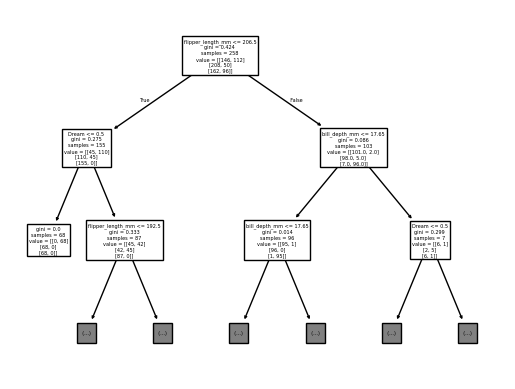

In [162]:
tree.plot_tree(
    clf, max_depth=2, feature_names=feature_names, class_names=list(class_names)
)

In [163]:
text_representation = tree.export_text(
    clf, feature_names=feature_names, class_names=list(class_names)
)
print(text_representation)

|--- flipper_length_mm <= 206.50
|   |--- Dream <= 0.50
|   |   |--- class: 1
|   |--- Dream >  0.50
|   |   |--- flipper_length_mm <= 192.50
|   |   |   |--- body_mass_g <= 3712.50
|   |   |   |   |--- flipper_length_mm <= 186.00
|   |   |   |   |   |--- body_mass_g <= 3675.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- body_mass_g >  3675.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- flipper_length_mm >  186.00
|   |   |   |   |   |--- bill_depth_mm <= 16.75
|   |   |   |   |   |   |--- bill_depth_mm <= 16.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- bill_depth_mm >  16.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- bill_depth_mm >  16.75
|   |   |   |   |   |   |--- bill_depth_mm <= 18.65
|   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |--- bill_depth_mm >  18.65
|   |   |   |   |   |   |   |--- class: 2
|   |   |   |--- body_mass_g >  3712.50
|   |   |   |   |--- class: 1
|   | 